# ✈️ Phase 1: Problem Formulation

## 🗂️ Dataset
- **Name:** Flight Delay and Cancellation
- **Source:** U.S. Department of Transportation On-Time Performance Reporting System
- **Description:** Each row corresponds to a scheduled domestic US flight with details about times, airlines, routes, and delays.
- [Kaggle Dataset Link](https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023/data)

## ❗ Problem
Predict and analyze arrival delays in US domestic flights. Focus:
- Identify factors influencing arrival delays.
- Predict delays before departure.
- Detect patterns in airline and airport performance.

## 🎯 Objectives
- **Regression Task:** Predict arrival delay duration (minutes) based on schedule, airline, route, distance, and operational factors.
- **Classification Task:** Categorize flights into:
  - ✅ On-time (<15-min delay)
  - ⏱️ Short delay (15–30 min)
  - ⏳ Long delay (>30 min)
- **Clustering Task:** Identify operational patterns in airports/airlines based on delays and route profiles.
- **Hypothesis Testing:**
  - ✈️ Are certain airlines systematically delayed?
  - 🌦️ Does weather significantly impact flight delays?


## 🏆 Success Criteria

The success of this project will be measured by the ability to **accurately predict and categorize flight delays** using only information known before departure. For the regression task, success means achieving reasonably low prediction errors for arrival delays, demonstrating that key factors such as airline, route, schedule, and distance are properly captured by the model. For the classification task, success is defined by the model correctly identifying on-time, short, and long delay flights with high accuracy, precision, and recall.

Additionally, exploratory analysis and clustering should reveal **meaningful patterns in operational performance**, such as identifying consistently delayed airlines, airports with frequent congestion, or time periods prone to delays. Finally, hypothesis testing should provide **statistically valid insights** into the factors that influence flight delays, supporting actionable conclusions. Overall, a successful project will combine **predictive performance, data-driven insights, and clear communication** in the notebook.

## 🗂️ Data Description

The dataset contains detailed records of U.S. domestic flights from 2019 to 2023. Each row corresponds to a single scheduled flight, with columns covering flight information, scheduled and actual times, delays, distances, and operational indicators. The main columns are:

**Flight-related:**
- `FL_DATE`: Date of the flight (YYYY-MM-DD)
- `AIRLINE`: Airline name
- `AIRLINE_DOT`: Standardized airline name by the U.S. Department of Transportation
- `AIRLINE_CODE`: Two-letter IATA airline code
- `DOT_CODE`: Unique DOT identifier for the airline
- `FL_NUMBER`: Flight number assigned by the airline
- `ORIGIN`: IATA code of departure airport
- `ORIGIN_CITY`: City and state of departure airport
- `DEST`: IATA code of destination airport
- `DEST_CITY`: City and state of destination airport

**Scheduled and actual times:**
- `CRS_DEP_TIME`: Scheduled departure time
- `DEP_TIME`: Actual departure time
- `CRS_ARR_TIME`: Scheduled arrival time
- `ARR_TIME`: Actual arrival time

**Delay metrics:**
- `DEP_DELAY`: Departure delay in minutes (negative indicates early departure)
- `ARR_DELAY`: Arrival delay in minutes (used as target for regression/classification)
- `TAXI_OUT`: Gate-to-wheels-off time (minutes)
- `TAXI_IN`: Wheels-on-to-gate time (minutes)
- `WHEELS_OFF`: Time aircraft leaves the ground
- `WHEELS_ON`: Time aircraft touches down

**Flight duration and distance:**
- `CRS_ELAPSED_TIME`: Scheduled total flight time (minutes)
- `ELAPSED_TIME`: Actual total flight time (minutes)
- `AIR_TIME`: Time spent in the air (minutes)
- `DISTANCE`: Distance between origin and destination (miles)

**Flight status indicators:**
- `CANCELLED`: Binary (1 if canceled, 0 otherwise)
- `CANCELLATION_CODE`: Reason for cancellation (e.g., weather, carrier, airspace)
- `DIVERTED`: Binary (1 if diverted)

**Causes of delay (minutes, typically for flights delayed ≥15 min):**
- `DELAY_DUE_CARRIER`: Delay due to airline issues
- `DELAY_DUE_WEATHER`: Delay due to weather
- `DELAY_DUE_NAS`: Delay due to National Airspace System (e.g., congestion)
- `DELAY_DUE_SECURITY`: Delay due to security issues
- `DELAY_DUE_LATE_AIRCRAFT`: Delay caused by late arrival of aircraft from previous flight

> **Note:** Additional **engineered features** will be created later in the feature engineering phase to improve model performance.

# ✈️ Phase 2: Data Analysis and Cleansing

## 🧹 2.1 Pre-processing
In this phase, we will prepare the dataset for analysis and modeling. This includes:
- Removing canceled or diverted flights.
- Dropping columns that cause data leakage.
- Handling missing values.
- Ensuring correct data types and removing duplicates if necessary.

> **Note:** Each step will be explained in detail as we progress, so the reasoning behind every preprocessing decision is clear.


## Load Dataset

We start by loading the CSV file into a DataFrame and creating a copy (`df_eda`) for exploratory data analysis before any preprocessing.
This allows us to inspect the raw dataset without modifying it.

In [61]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('../ProjectDatasets/flights_sample_3m.csv')
df_eda = df.copy()  # Save original for EDA

# Display initial info
display(df.head())
print("Dataset shape:", df.shape)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


Dataset shape: (3000000, 32)


## Remove Canceled/Diverted Flights and Missing Values

Canceled or diverted flights do not have meaningful arrival delay values, so we remove them.
We also remove rows with missing scheduled flight time (`CRS_ELAPSED_TIME`) or missing arrival delay (`ARR_DELAY`).

Finally, we reset the DataFrame index to keep the row numbers consistent.

In [62]:
# Remove canceled or diverted flights
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

# Drop rows with missing scheduled flight time
df.dropna(subset=['CRS_ELAPSED_TIME'], inplace=True)

# Drop rows with missing arrival delay
df.dropna(subset=['ARR_DELAY'], inplace=True)

# Drop rows with DISTANCE between 50 and 5500 (Valid range)
df = df[(df['DISTANCE'] >= 50) & (df['DISTANCE'] <= 5500)]

# Reset index
df = df.reset_index(drop=True)

# Saving for hyp
df_hyp = df.copy()

# Show updated dataset
display(df.head())
print("Dataset shape:", df.shape)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


Dataset shape: (2913200, 32)


## Drop Leakage Columns

These columns contain information that would not be known before the flight or directly encode the target (`ARR_DELAY`).
Dropping them ensures our predictive models are **fair and realistic**.

In [63]:
# Columns that leak future information or are irrelevant or redundant
cols_to_drop = [
    'DEP_DELAY', 'DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT',
    'ARR_TIME','DEP_TIME','WHEELS_OFF','WHEELS_ON','TAXI_OUT','TAXI_IN','ELAPSED_TIME','AIR_TIME',
    'CANCELLED','CANCELLATION_CODE','DIVERTED',
    'AIRLINE','AIRLINE_DOT','DOT_CODE','FL_NUMBER','ORIGIN_CITY','DEST_CITY'
]

df.drop(columns=cols_to_drop, inplace=True)

# Show updated dataset
display(df.head())
print(list(df.columns))

,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,2019-01-09,UA,FLL,EWR,1155,1501,-14.0,186.0,1065.0
1,2022-11-19,DL,MSP,SEA,2120,2315,-5.0,235.0,1399.0
2,2022-07-22,UA,DEN,MSP,954,1252,0.0,118.0,680.0
3,2023-03-06,DL,MSP,SFO,1609,1829,24.0,260.0,1589.0
4,2020-02-23,NK,MCO,DFW,1840,2041,-1.0,181.0,985.0


['FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'ARR_DELAY', 'CRS_ELAPSED_TIME', 'DISTANCE']


## Handle Outliers

We use the Interquartile Range (IQR) method to detect extreme values in numeric columns (`CRS_ELAPSED_TIME`, `DISTANCE`).
Outliers are replaced with the median of the column to reduce their impact on modeling while preserving the dataset size.

In [64]:
# Identify numeric columns to check for outliers
numeric_cols_preproc = ['CRS_ELAPSED_TIME', 'DISTANCE']

for col in numeric_cols_preproc:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Replace outliers with NaN and fill with median
    df[col] = np.where((df[col] < lower) | (df[col] > upper), np.nan, df[col])
    df[col] = df[col].fillna(df[col].median())

# Checks for any nans in the cols
pd.isnull(df).sum().to_frame().T

,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,0,0,0,0,0,0,0,0,0


## Save Clean Dataset

The preprocessing phase is complete.
We now have a clean dataset (`df_cleaned`) ready for **EDA, feature engineering, and modeling**.
Additional features will be added in the next phase to improve model performance.

In [65]:
# Save a cleaned copy for later phases
df_cleaned = df.copy()
# Optionally, export to CSV
# df_cleaned.to_csv('flights_cleaned.csv', index=False)

df_cleaned.head()

,FL_DATE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE
0,2019-01-09,UA,FLL,EWR,1155,1501,-14.0,186.0,1065.0
1,2022-11-19,DL,MSP,SEA,2120,2315,-5.0,235.0,1399.0
2,2022-07-22,UA,DEN,MSP,954,1252,0.0,118.0,680.0
3,2023-03-06,DL,MSP,SFO,1609,1829,24.0,260.0,1589.0
4,2020-02-23,NK,MCO,DFW,1840,2041,-1.0,181.0,985.0


# ✈️ Phase 2: Data Analysis and Cleansing

## 📊 2.2 Exploratory Data Analysis (EDA)

In this phase, we explore the dataset to understand distributions, correlations, patterns, and potential outliers. Insights gained here will guide feature engineering and model selection.

### 2.2.1 Summary Statistics

In this step, we calculate basic descriptive statistics for the key numeric features in the dataset:

- `CRS_ELAPSED_TIME`: Scheduled flight duration
- `DISTANCE`: Distance between origin and destination airports
- `ARR_DELAY`: Arrival delay in minutes

**Purpose:**
- Understand the central tendency (mean, median) and variability (standard deviation) of each feature.
- Identify potential outliers or unusual values that might require attention in later phases.

> **Note:** Summary statistics provide a first glance at the dataset and help guide further EDA and feature engineering decisions.

In [67]:
# Numeric columns for analysis
numeric_cols_eda = ['CRS_ELAPSED_TIME', 'DISTANCE', 'ARR_DELAY']

# Summary statistics for numeric columns
numeric_stats = df_eda[numeric_cols_eda].describe().T
numeric_stats['median'] = df_eda[numeric_cols_eda].median()
numeric_stats['mean'] = df_eda[numeric_cols_eda].mean()
numeric_stats['std_dev'] = df_eda[numeric_cols_eda].std()

display(numeric_stats)

,count,mean,std,min,25%,50%,75%,max,median,std_dev
CRS_ELAPSED_TIME,2999986.0,142.275807,71.556690,1.0,90.0,125.0,172.0,705.0,125.0,71.556690
DISTANCE,3000000.0,809.361552,587.893938,29.0,377.0,651.0,1046.0,5812.0,651.0,587.893938
ARR_DELAY,2913802.0,4.260858,51.174824,-96.0,-16.0,-7.0,7.0,2934.0,-7.0,51.174824


#### Top Airlines by Flight Count

We examine the frequency of flights per airline to understand which carriers dominate the dataset.

> **Visual:** Horizontal bar chart showing the top 10 airlines by number of flights.
> **Purpose:** This helps identify which airlines contribute most to the dataset and may influence delay patterns.

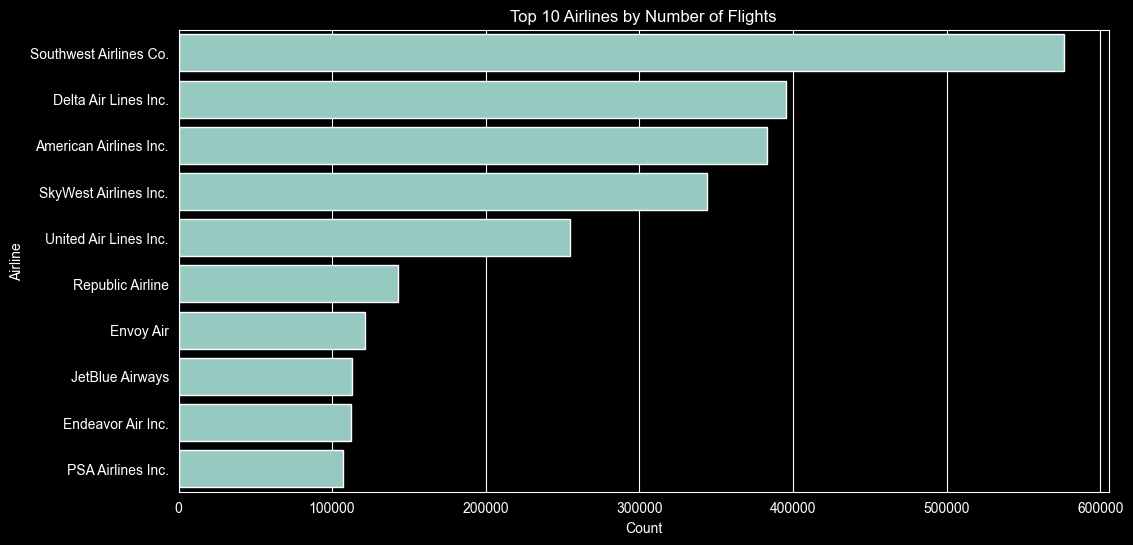

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 Airlines by number of flights
plt.figure(figsize=(12,6))
sns.countplot(
    y='AIRLINE',
    data=df_eda,
    order=df_eda['AIRLINE'].value_counts().index[:10]
)
plt.title("Top 10 Airlines by Number of Flights")
plt.xlabel("Count")
plt.ylabel("Airline")
plt.show()

#### Distribution of Numeric Features

We visualize the distribution of key numeric features to understand their spread, central tendency, and potential outliers.

- `CRS_ELAPSED_TIME`: Scheduled flight duration
- `DISTANCE`: Distance between origin and destination airports
- `ARR_DELAY`: Arrival delay in minutes

> **Visual:** Histograms with Kernel Density Estimate (KDE) curves.
> **Purpose:** This helps identify skewness, unusual values, and patterns in the dataset.

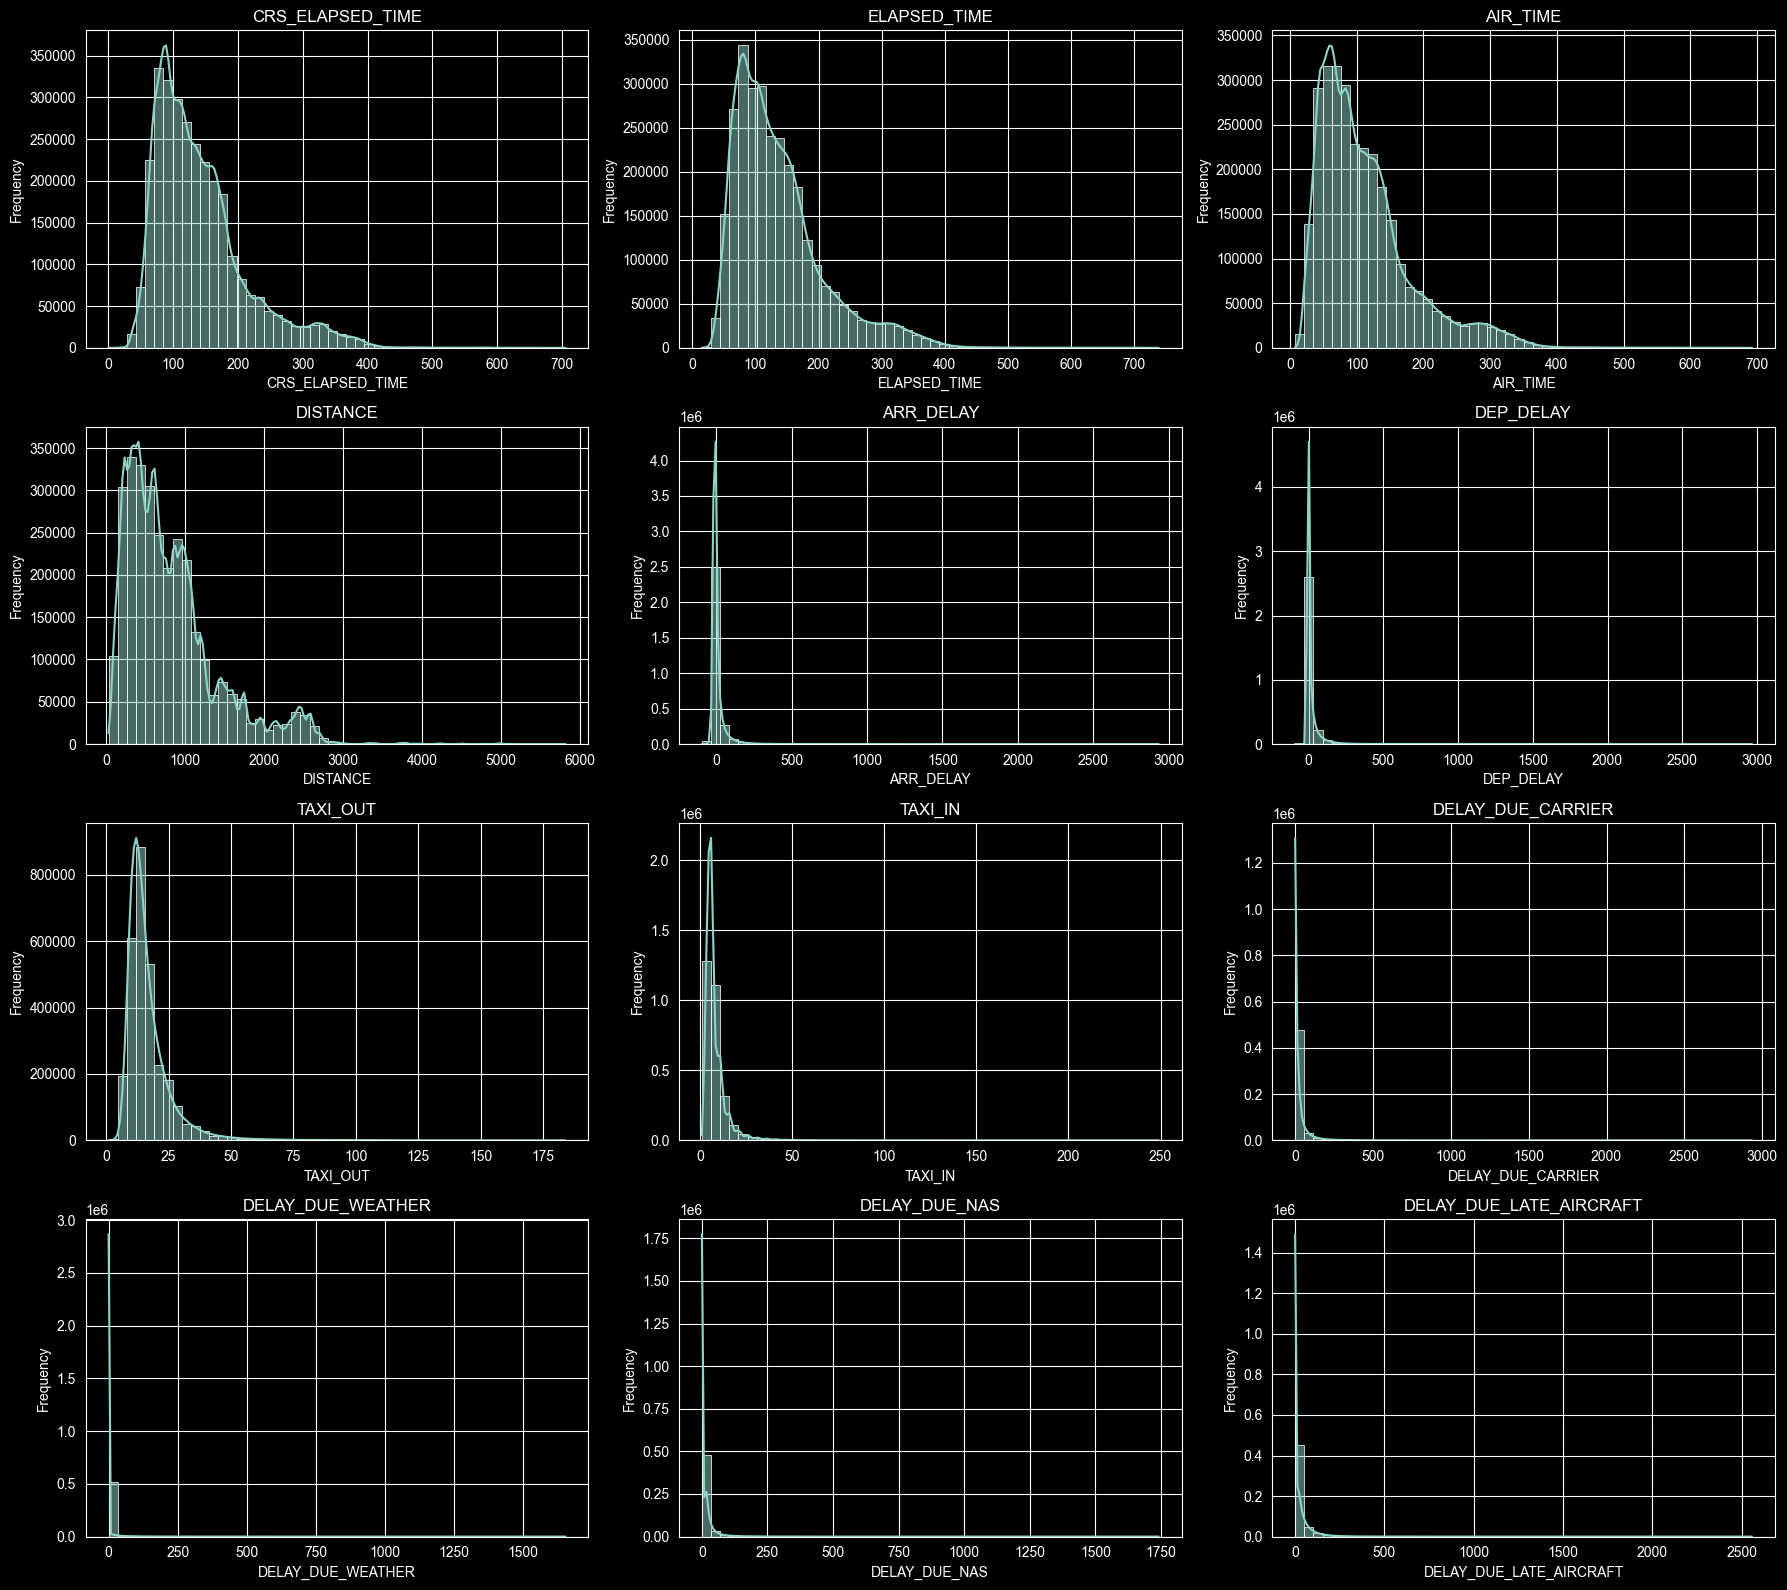

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols_eda = [
    'CRS_ELAPSED_TIME',  # scheduled flight time
    'ELAPSED_TIME',      # actual flight time
    'AIR_TIME',          # time in the air
    'DISTANCE',          # distance between airports
    'ARR_DELAY',         # arrival delay (target)
    'DEP_DELAY',         # departure delay
    'TAXI_OUT',          # time from gate to takeoff
    'TAXI_IN',           # time from landing to gate
    'DELAY_DUE_CARRIER', # delay caused by airline
    'DELAY_DUE_WEATHER', # weather delays
    'DELAY_DUE_NAS',     # national airspace system
    'DELAY_DUE_LATE_AIRCRAFT'  # late aircraft cascading delays
]

# Horizontal layout: 3 plots per row
n_cols = 3
n_rows = (len(numeric_cols_eda) + n_cols - 1) // n_cols

plt.figure(figsize=(6*n_cols, 4*n_rows))

for i, col in enumerate(numeric_cols_eda, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_eda[col], bins=50, kde=True)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()